In [20]:
# cell [0] 
import matplotlib.pyplot as plt  
import numpy as np 
import tensorflow as tf 
import os
import glob
import random
from tqdm import tqdm
from pathlib import Path 
from tensorflow.keras import layers, optimizers, metrics, Model 
from tensorflow.keras.applications import resnet
from tensorflow.keras import mixed_precision

In [21]:
target_shape = (150, 150)  # Ukuran target untuk semua gambar input (width, height)
mixed_precision.set_global_policy('mixed_float16')

In [22]:
# cell [1]

#  Konfigurasi GPU
print("Mengecek ketersediaan GPU...")
physical_devices = tf.config.list_physical_devices('GPU')

if len(physical_devices) > 0:
    print(f"Ditemukan {len(physical_devices)} GPU:")
    for device in physical_devices:
        print(f" - {device.name}")
    
    # Konfigurasi memori GPU - mencegah alokasi memori berlebihan
    try:
        # Aktifkan memory growth - alokasi memori sesuai kebutuhan
        for device in physical_devices:
            tf.config.experimental.set_memory_growth(device, True)
            print(f"Memory growth diaktifkan untuk {device.name}")
    except Exception as e:
        print(f"Gagal mengatur memory growth: {e}")
    
    # Informasi GPU
    try:
        gpu_info = tf.config.experimental.get_device_details(physical_devices[0])
        print(f"Menggunakan GPU: {gpu_info.get('device_name', 'Unknown')}")
    except:
        print(f"Menggunakan GPU: {physical_devices[0].name}")
else:
    print("Tidak ada GPU yang tersedia, menggunakan CPU")

Mengecek ketersediaan GPU...
Ditemukan 1 GPU:
 - /physical_device:GPU:0
Memory growth diaktifkan untuk /physical_device:GPU:0
Menggunakan GPU: NVIDIA GeForce RTX 3050 Laptop GPU


In [4]:
# cell [2]
base_path = Path("../Clustering/hasil_clustering")  # Path ke folder hasil clustering, perlu disesuaikan

In [5]:
# cell [3]
def preprocess_image(filename):
    """
    Load file gambar, preprocess, dan resize ke ukuran target.
    """
    image_string = tf.io.read_file(filename)  # Membaca file gambar sebagai string byte
    image = tf.image.decode_jpeg(image_string, channels=3)  # Decode JPEG ke tensor RGB
    image = tf.image.convert_image_dtype(image, tf.float32)  # Konversi ke float32 dan normalisasi ke [0,1]
    image = tf.image.resize(image, target_shape)  # Resize ke ukuran target
    return image

def preprocess_triplets(anchor, positive, negative):
    """
    Preprocess triplet gambar (anchor, positive, negative)
    """
    return (
        preprocess_image(anchor),  # Preprocess gambar anchor
        preprocess_image(positive),  # Preprocess gambar positive
        preprocess_image(negative),  # Preprocess gambar negative
    )

In [6]:
# cell [4]

def create_triplet_dataset(base_path, num_clusters=611):
    """
    Membuat dataset dengan strategi rotasi anchor dan augmentasi,
    dengan penanganan khusus untuk cluster yang hanya memiliki satu gambar
    """
    all_triplets = []
    single_image_clusters = []  # Untuk menyimpan cluster dengan satu gambar
    
    # Kumpulkan informasi cluster terlebih dahulu
    valid_clusters = []
    cluster_to_images = {}
    
    for cluster_id in range(1, num_clusters + 1):
        cluster_path = base_path / f"cluster_{cluster_id}"
        if not cluster_path.exists():
            continue
            
        images = list(cluster_path.glob("*.png")) + list(cluster_path.glob("*.jpg")) + list(cluster_path.glob("*.jpeg"))
        
        if len(images) == 0:
            continue
        elif len(images) == 1:
            single_image_clusters.append(cluster_id)
        else:
            valid_clusters.append(cluster_id)
        
        cluster_to_images[cluster_id] = images
    
    print(f"Total cluster: {len(valid_clusters) + len(single_image_clusters)}")
    print(f"Cluster dengan multiple gambar: {len(valid_clusters)}")
    print(f"Cluster dengan satu gambar: {len(single_image_clusters)}")
    
    # Fungsi augmentasi yang lebih kuat untuk single-image clusters
    def strong_augment(image_path):
        """Membuat versi yang sangat berbeda dari gambar yang sama"""
        img = preprocess_image(image_path).numpy()
        
        # Buat beberapa versi augmentasi yang berbeda
        augmented_versions = []
        
        # Versi 1: Flip horizontal
        img1 = tf.image.flip_left_right(img).numpy()
        augmented_versions.append(img1)
        
        # Versi 2: Brightness up
        img2 = tf.image.adjust_brightness(img, 0.3).numpy()
        augmented_versions.append(img2)
        
        # Versi 3: Brightness down
        img3 = tf.image.adjust_brightness(img, -0.3).numpy()
        augmented_versions.append(img3)
        
        # Versi 4: Contrast up
        img4 = tf.image.adjust_contrast(img, 1.5).numpy()
        augmented_versions.append(img4)
        
        # Versi 5: Saturation change
        img5 = tf.image.adjust_saturation(img, 1.5).numpy()
        augmented_versions.append(img5)
        
        return augmented_versions
    
    # Buat triplet dari cluster dengan multiple gambar
    for cluster_id in valid_clusters:
        images = cluster_to_images[cluster_id]
        
        # Buat kombinasi anchor-positive dari cluster yang sama
        for i, anchor in enumerate(images):
            # Gunakan beberapa positive dari cluster yang sama
            for j in range(min(3, len(images))):
                positive = images[(i + j + 1) % len(images)]
                
                # Pilih beberapa negative dari cluster lain (termasuk single-image clusters)
                other_clusters = [x for x in valid_clusters + single_image_clusters 
                                if x != cluster_id]
                
                if not other_clusters:
                    continue
                    
                # Ambil beberapa negative untuk setiap pair anchor-positive
                for _ in range(2):
                    neg_cluster = np.random.choice(other_clusters)
                    neg_images = cluster_to_images[neg_cluster]
                    
                    if not neg_images:
                        continue
                        
                    negative = np.random.choice(neg_images)
                    all_triplets.append((str(anchor), str(positive), str(negative)))
    
    # Buat triplet dari cluster dengan satu gambar menggunakan augmentasi
    for cluster_id in single_image_clusters:
        image = cluster_to_images[cluster_id][0]  # Satu-satunya gambar
        
        # Buat versi yang sangat berbeda dari gambar yang sama
        augmented_versions = strong_augment(str(image))
        
        # Gunakan gambar asli sebagai anchor dan versi augmentasi sebagai positive
        for i, aug_img in enumerate(augmented_versions):
            # Simpan versi augmentasi ke file sementara
            aug_path = str(image) + f".aug_{i}.jpg"
            tf.keras.preprocessing.image.save_img(aug_path, aug_img)
            
            # Pilih beberapa negative dari cluster lain
            other_clusters = [x for x in valid_clusters + single_image_clusters 
                            if x != cluster_id]
            
            if not other_clusters:
                continue
                
            # Ambil beberapa negative untuk setiap pair anchor-positive
            for _ in range(2):
                neg_cluster = np.random.choice(other_clusters)
                neg_images = cluster_to_images[neg_cluster]
                
                if not neg_images:
                    continue
                    
                negative = np.random.choice(neg_images)
                all_triplets.append((str(image), aug_path, str(negative)))
    
    # Acak dataset
    np.random.shuffle(all_triplets)
    
    # Split train-validation
    train_size = int(0.8 * len(all_triplets))
    train_triplets = all_triplets[:train_size]
    val_triplets = all_triplets[train_size:]
    
    print(f"Total triplet: {len(all_triplets)}")
    print(f"Training triplet: {len(train_triplets)}")
    print(f"Validation triplet: {len(val_triplets)}")
    
    # Buat tf.data.Dataset dengan augmentasi
    def augment_image(image):
        image = tf.image.random_flip_left_right(image)
        image = tf.image.random_brightness(image, 0.2)
        image = tf.image.random_contrast(image, 0.8, 1.2)
        return image
    
    def preprocess_triplets_with_aug(anchor, positive, negative):
        return (
            augment_image(preprocess_image(anchor)),
            augment_image(preprocess_image(positive)),
            augment_image(preprocess_image(negative)),
        )
    
    def create_tf_dataset(triplets, batch_size=32):
        anchors = [t[0] for t in triplets]
        positives = [t[1] for t in triplets]
        negatives = [t[2] for t in triplets]
        
        dataset = tf.data.Dataset.from_tensor_slices((anchors, positives, negatives))
        dataset = dataset.map(preprocess_triplets_with_aug)
        dataset = dataset.batch(batch_size)
        dataset = dataset.prefetch(tf.data.AUTOTUNE)
        return dataset
    
    train_dataset = create_tf_dataset(train_triplets)
    val_dataset = create_tf_dataset(val_triplets)
    
    return train_dataset, val_dataset

In [7]:
# cell [5]
# Gunakan fungsi untuk membuat dataset
train_dataset, val_dataset = create_triplet_dataset(base_path)

Total cluster: 611
Cluster dengan multiple gambar: 611
Cluster dengan satu gambar: 0
Total triplet: 41066
Training triplet: 32852
Validation triplet: 8214


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.07650298..1.0177957].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.06295887..0.8255251].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.071309686..1.1568035].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.01642567..1.102958].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.038530767..0.9651034].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.13074863..1.0629281].


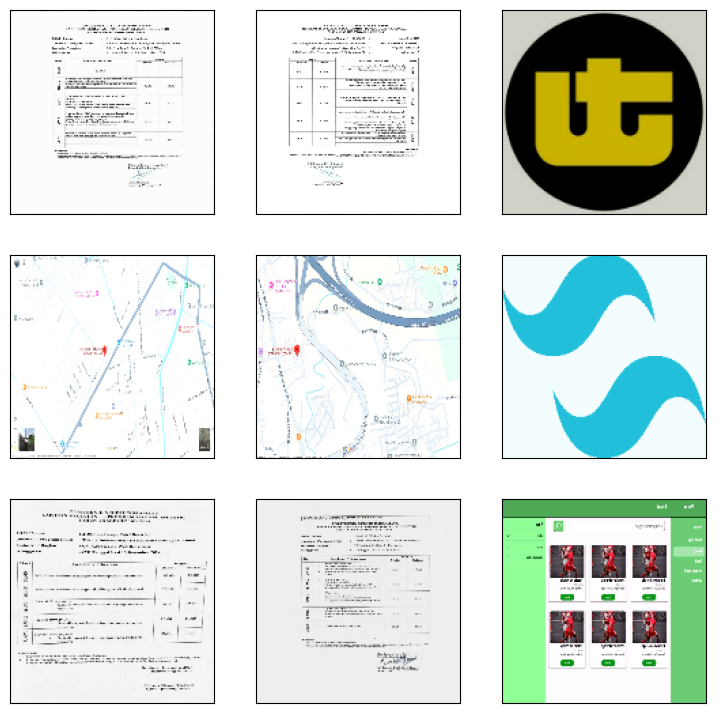

In [8]:
# cell [6]
def visualize(anchor, positive, negative):
    """Visualize triplet dari dataset"""

    def show(ax, image):
        ax.imshow(image)  # Tampilkan gambar
        ax.get_xaxis().set_visible(False)  # Sembunyikan sumbu x
        ax.get_yaxis().set_visible(False)  # Sembunyikan sumbu y

    fig = plt.figure(figsize=(9, 9))  # Buat figure dengan ukuran 9x9

    axs = fig.subplots(3, 3)  # Buat grid 3x3 subplot
    for i in range(3):  # Untuk 3 baris
        show(axs[i, 0], anchor[i])  # Tampilkan anchor di kolom 1
        show(axs[i, 1], positive[i])  # Tampilkan positive di kolom 2
        show(axs[i, 2], negative[i])  # Tampilkan negative di kolom 3


visualize(*list(train_dataset.take(1).as_numpy_iterator())[0])  # Visualisasi batch pertama dari dataset

In [12]:
# cell [7]
base_cnn = resnet.ResNet50(
    weights="imagenet", input_shape=target_shape + (3,), include_top=False
)

flatten = layers.Flatten()(base_cnn.output)
dense1 = layers.Dense(512, activation="relu")(flatten)
dense1 = layers.BatchNormalization()(dense1)
dense2 = layers.Dense(256, activation="relu")(dense1)
dense2 = layers.BatchNormalization()(dense2)
output = layers.Dense(256)(dense2)

embedding = Model(base_cnn.input, output, name="Embedding")

trainable = False
for layer in base_cnn.layers:
    if layer.name == "conv5_block1_out":
        trainable = True
    layer.trainable = trainable

In [10]:
# cell [8]
class DistanceLayer(layers.Layer):
    """
    This layer is responsible for computing the distance between the anchor
    embedding and the positive embedding, and the anchor embedding and the
    negative embedding.
    """

    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def call(self, anchor, positive, negative):
        ap_distance = tf.reduce_sum(tf.square(anchor - positive), -1)  # Jarak Euclidean kuadrat anchor-positive
        an_distance = tf.reduce_sum(tf.square(anchor - negative), -1)  # Jarak Euclidean kuadrat anchor-negative
        return (ap_distance, an_distance)  # Return tuple jarak


anchor_input = layers.Input(name="anchor", shape=target_shape + (3,))
positive_input = layers.Input(name="positive", shape=target_shape + (3,))
negative_input = layers.Input(name="negative", shape=target_shape + (3,))

distances = DistanceLayer()(
    embedding(resnet.preprocess_input(anchor_input)),
    embedding(resnet.preprocess_input(positive_input)),
    embedding(resnet.preprocess_input(negative_input)),
)

siamese_network = Model(
    inputs=[anchor_input, positive_input, negative_input], outputs=distances
)


In [11]:
# cell [9]
def plot_training_history(history, epochs=None):
    def moving_average(data, window_size=3):
        return np.convolve(data, np.ones(window_size)/window_size, mode='valid')
    
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12))
    
    # Smooth the curves
    train_loss = moving_average(history.history['loss'])
    val_loss = moving_average(history.history['val_loss'])
    epochs_range = range(len(train_loss))
    
    # Plot Loss
    ax1.plot(epochs_range, train_loss, 
             label='train', color='#1f77b4', linewidth=2)
    ax1.plot(epochs_range, val_loss, 
             label='validation', color='#ff7f0e', linewidth=2)
    ax1.set_title('Model Loss', pad=20, size=14, weight='bold')
    ax1.set_xlabel('epoch')
    ax1.set_ylabel('loss')
    ax1.legend(loc='upper right')
    ax1.grid(True, linestyle='--', alpha=0.7)
    ax1.set_ylim([0, 0.25])  # Set consistent y-axis limits
    
    # Calculate and smooth accuracy
    train_acc = moving_average([1 - min(l, 1) for l in history.history['loss']])
    val_acc = moving_average([1 - min(l, 1) for l in history.history['val_loss']])
    
    # Plot Accuracy
    ax2.plot(epochs_range, train_acc, 
             label='train', color='#1f77b4', linewidth=2)
    ax2.plot(epochs_range, val_acc, 
             label='validation', color='#ff7f0e', linewidth=2)
    ax2.set_title('Model Accuracy', pad=20, size=14, weight='bold')
    ax2.set_xlabel('epoch')
    ax2.set_ylabel('accuracy')
    ax2.set_ylim([0.5, 1.0])  # Set consistent y-axis limits
    ax2.legend(loc='lower right')
    ax2.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()
    
    # Tampilkan nilai loss terbaik
    best_train_loss = min(history.history['loss'])
    best_val_loss = min(history.history['val_loss'])
    best_epoch = np.argmin(history.history['val_loss']) + 1

    print(f"\nHasil Training Terbaik:")
    print(f"Epoch terbaik: {best_epoch}")
    print(f"Training loss terbaik: {best_train_loss:.6f}")
    print(f"Validation loss terbaik: {best_val_loss:.6f}")

In [12]:
# cell [10]
class SiameseModel(Model):
    """The Siamese Network model with a custom training and testing loops."""

    def __init__(self, siamese_network, margin=0.5):
        super().__init__()
        self.siamese_network = siamese_network
        self.margin = margin
        self.loss_tracker = metrics.Mean(name="loss")
        # Flag untuk mendeteksi mixed precision
        self.using_mixed_precision = mixed_precision.global_policy().name == 'mixed_float16'

    def call(self, inputs):
        return self.siamese_network(inputs)

    def train_step(self, data):
        with tf.GradientTape() as tape:
            loss = self._compute_loss(data)
            
            # Jika menggunakan mixed precision, dapatkan scaled loss
            if self.using_mixed_precision:
                scaled_loss = self.optimizer.get_scaled_loss(loss)
            else:
                scaled_loss = loss

        # Dapatkan gradients
        if self.using_mixed_precision:
            scaled_gradients = tape.gradient(scaled_loss, self.siamese_network.trainable_weights)
            gradients = self.optimizer.get_unscaled_gradients(scaled_gradients)
        else:
            gradients = tape.gradient(loss, self.siamese_network.trainable_weights)

        # Terapkan gradients
        self.optimizer.apply_gradients(
            zip(gradients, self.siamese_network.trainable_weights)
        )

        # Update loss tracker
        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}

    def test_step(self, data):
        loss = self._compute_loss(data)
        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}

    def _compute_loss(self, data):
        ap_distance, an_distance = self.siamese_network(data)
        loss = ap_distance - an_distance
        loss = tf.maximum(loss + self.margin, 0.0)
        return loss

    @property
    def metrics(self):
        return [self.loss_tracker]


In [13]:
# cell [11]
siamese_model = SiameseModel(siamese_network)
siamese_model.compile(
    optimizer=optimizers.Adam(0.0001),
    weighted_metrics=[]
)

history = siamese_model.fit(
    train_dataset, 
    epochs=80, 
    validation_data=val_dataset,
)


Epoch 1/80
1027/1027 [==============================] - 534s 507ms/step - loss: 0.0916 - val_loss: 0.0758
Epoch 2/80
1027/1027 [==============================] - 537s 522ms/step - loss: 0.0601 - val_loss: 0.0596
Epoch 3/80
1027/1027 [==============================] - 512s 499ms/step - loss: 0.0490 - val_loss: 0.0458
Epoch 4/80
1027/1027 [==============================] - 526s 512ms/step - loss: 0.0404 - val_loss: 0.0420
Epoch 5/80
1027/1027 [==============================] - 503s 490ms/step - loss: 0.0368 - val_loss: 0.0382
Epoch 6/80
1027/1027 [==============================] - 499s 486ms/step - loss: 0.0335 - val_loss: 0.0363
Epoch 7/80
1027/1027 [==============================] - 500s 486ms/step - loss: 0.0300 - val_loss: 0.0363
Epoch 8/80
1027/1027 [==============================] - 498s 485ms/step - loss: 0.0289 - val_loss: 0.0389
Epoch 9/80
1027/1027 [==============================] - 499s 486ms/step - loss: 0.0263 - val_loss: 0.0348
Epoch 10/80
1027/1027 [=======================

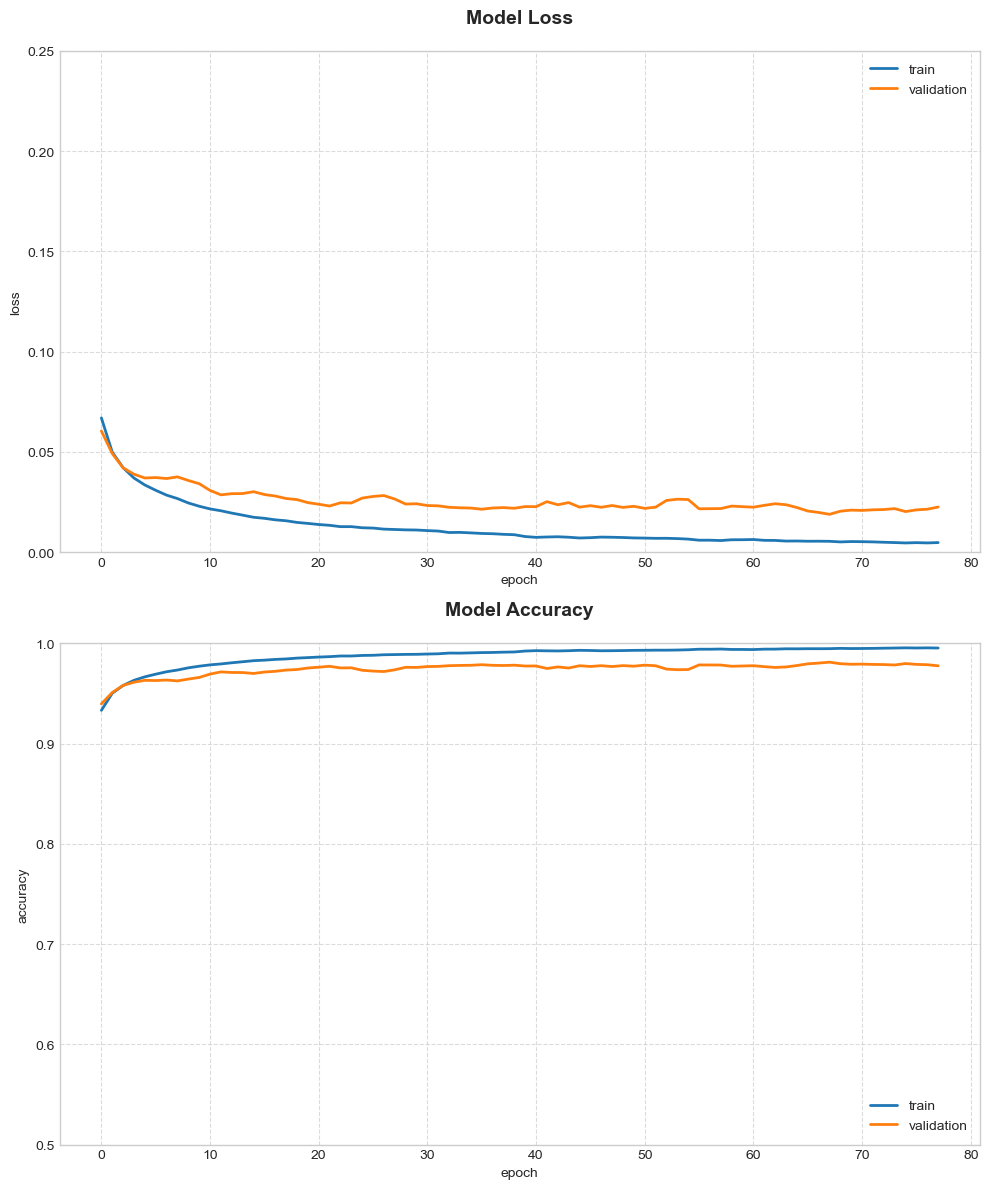


Hasil Training Terbaik:
Epoch terbaik: 69
Training loss terbaik: 0.004134
Validation loss terbaik: 0.018291


In [14]:
# Plot hasil training
plot_training_history(history)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0747996..1.0655503].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.15401523..1.0884296].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.06744641..1.0198141].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.11057925..0.79463106].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.10997939..1.0002453].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.09703195..1.1376585].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.2075

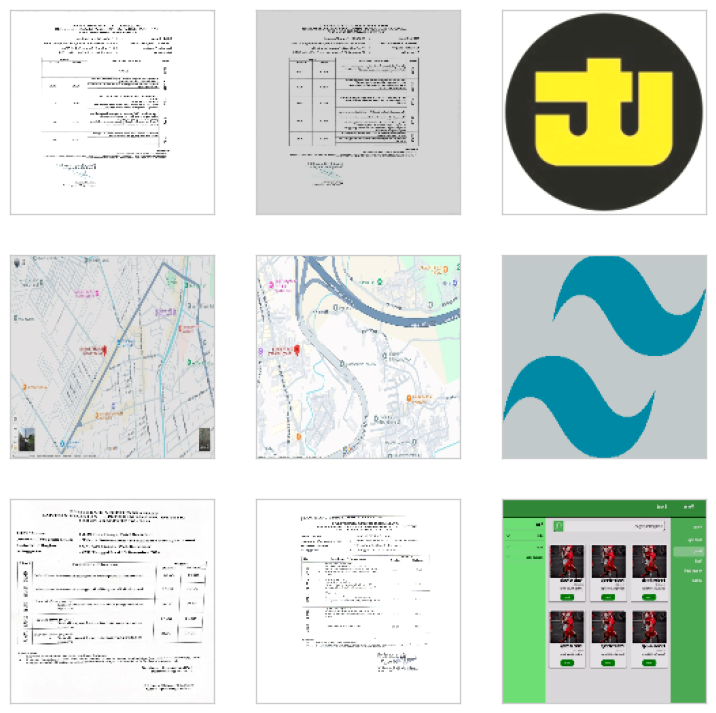

In [15]:
# cell [12]
sample = next(iter(train_dataset))  # Ambil batch pertama dari dataset
visualize(*sample)  # Visualisasi sampel

# Hitung embedding untuk sampel
anchor, positive, negative = sample
anchor_embedding, positive_embedding, negative_embedding = (
    embedding(resnet.preprocess_input(anchor)),  # Embedding anchor
    embedding(resnet.preprocess_input(positive)),  # Embedding positive
    embedding(resnet.preprocess_input(negative)),  # Embedding negative
)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.06994188..1.1228927].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.3139764..1.1270645].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.1739384..0.994913].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.1946438..0.81672776].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.5502266..1.1601421].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.069526315..1.0111289].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.1553312

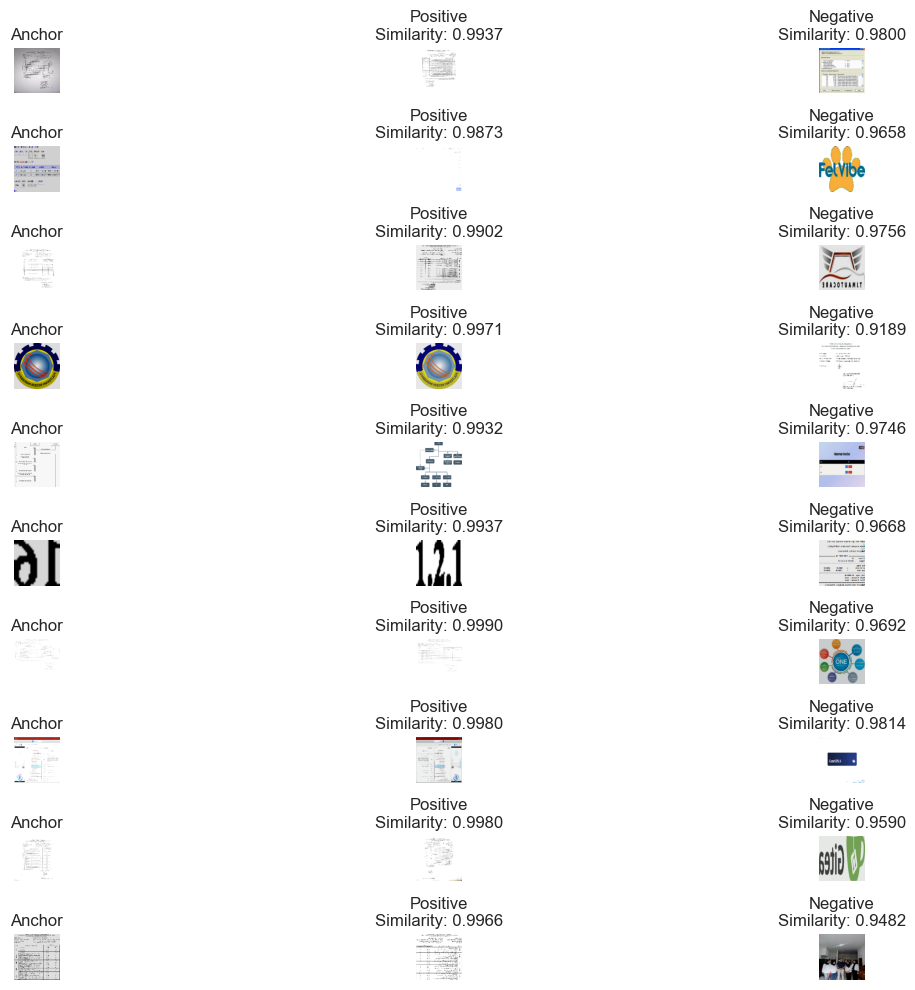


Statistik Similarity:
Rata-rata similarity anchor-positive: 0.9956
Rata-rata similarity anchor-negative: 0.9697
Min similarity anchor-positive: 0.9873
Max similarity anchor-negative: 0.9902


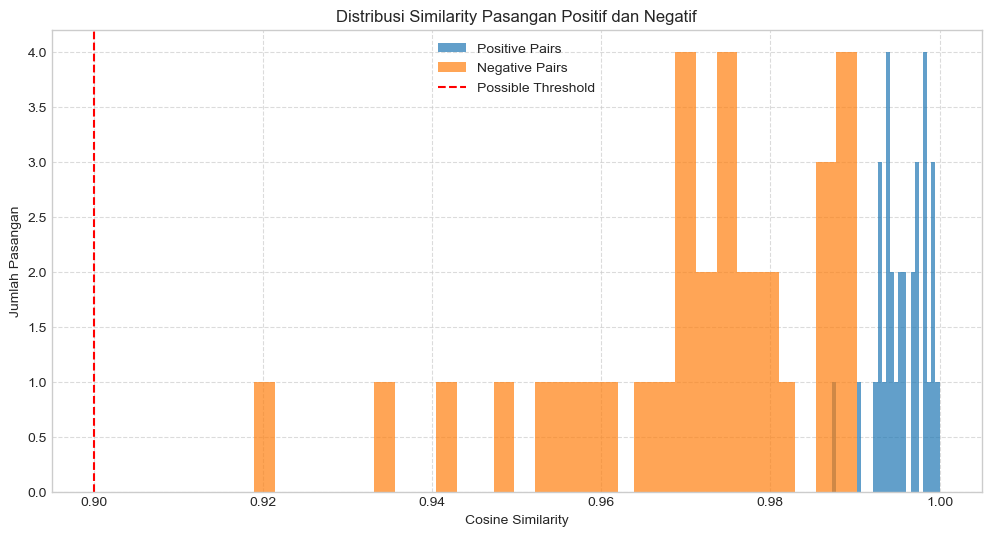


Evaluasi dengan Berbagai Threshold:
Threshold: 0.95, Precision: 0.5333, Recall: 1.0000, F1: 0.6957
Threshold: 0.96, Precision: 0.5714, Recall: 1.0000, F1: 0.7273
Threshold: 0.97, Precision: 0.6400, Recall: 1.0000, F1: 0.7805
Threshold: 0.98, Precision: 0.7805, Recall: 1.0000, F1: 0.8767
Threshold: 0.99, Precision: 0.9688, Recall: 0.9688, F1: 0.9688


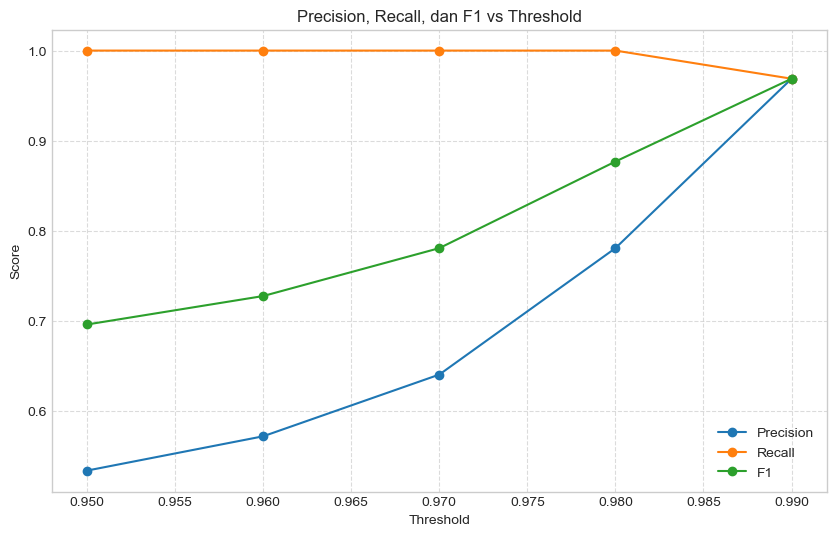

In [16]:
# cell [13]
# Fungsi cosine similarity tradisional
def cosine_similarity_traditional(a, b):
    """
    Menghitung cosine similarity antara dua tensor dengan pendekatan tradisional
    """
    # Normalisasi vektor
    a_norm = tf.nn.l2_normalize(a, axis=1)
    b_norm = tf.nn.l2_normalize(b, axis=1)
    
    # Hitung dot product
    similarity = tf.reduce_sum(a_norm * b_norm, axis=1)
    
    return similarity

# Ambil batch dari dataset validasi
val_batch = next(iter(val_dataset))
anchor_val, positive_val, negative_val = val_batch

# Hitung embedding untuk setiap gambar
anchor_embedding = embedding(resnet.preprocess_input(anchor_val))
positive_embedding = embedding(resnet.preprocess_input(positive_val))
negative_embedding = embedding(resnet.preprocess_input(negative_val))

# Hitung similarity antara anchor-positive dan anchor-negative
positive_similarity = cosine_similarity_traditional(anchor_embedding, positive_embedding)
negative_similarity = cosine_similarity_traditional(anchor_embedding, negative_embedding)

# Tampilkan hasil untuk beberapa sampel
num_samples = min(10, len(anchor_val))
plt.figure(figsize=(15, 10))

for i in range(num_samples):
    plt.subplot(num_samples, 3, i*3+1)
    plt.imshow(anchor_val[i])
    plt.title("Anchor")
    plt.axis('off')
    
    plt.subplot(num_samples, 3, i*3+2)
    plt.imshow(positive_val[i])
    plt.title(f"Positive\nSimilarity: {positive_similarity[i].numpy():.4f}")
    plt.axis('off')
    
    plt.subplot(num_samples, 3, i*3+3)
    plt.imshow(negative_val[i])
    plt.title(f"Negative\nSimilarity: {negative_similarity[i].numpy():.4f}")
    plt.axis('off')

plt.tight_layout()
plt.show()

# Tampilkan statistik similarity
print("\nStatistik Similarity:")
print(f"Rata-rata similarity anchor-positive: {tf.reduce_mean(positive_similarity).numpy():.4f}")
print(f"Rata-rata similarity anchor-negative: {tf.reduce_mean(negative_similarity).numpy():.4f}")
print(f"Min similarity anchor-positive: {tf.reduce_min(positive_similarity).numpy():.4f}")
print(f"Max similarity anchor-negative: {tf.reduce_max(negative_similarity).numpy():.4f}")

# Visualisasi distribusi similarity
plt.figure(figsize=(12, 6))
plt.hist(positive_similarity.numpy(), bins=30, alpha=0.7, label='Positive Pairs')
plt.hist(negative_similarity.numpy(), bins=30, alpha=0.7, label='Negative Pairs')
plt.axvline(x=0.9, color='r', linestyle='--', label='Possible Threshold')
plt.title('Distribusi Similarity Pasangan Positif dan Negatif')
plt.xlabel('Cosine Similarity')
plt.ylabel('Jumlah Pasangan')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Evaluasi dengan berbagai threshold
thresholds = [0.95, 0.96, 0.97, 0.98, 0.99]
results = []

for threshold in thresholds:
    # Hitung true positives, false positives, dll
    true_positives = tf.reduce_sum(tf.cast(positive_similarity >= threshold, tf.float32))
    false_negatives = tf.reduce_sum(tf.cast(positive_similarity < threshold, tf.float32))
    true_negatives = tf.reduce_sum(tf.cast(negative_similarity < threshold, tf.float32))
    false_positives = tf.reduce_sum(tf.cast(negative_similarity >= threshold, tf.float32))
    
    # Hitung precision, recall, F1
    precision = true_positives / (true_positives + false_positives + 1e-10)
    recall = true_positives / (true_positives + false_negatives + 1e-10)
    f1 = 2 * precision * recall / (precision + recall + 1e-10)
    
    results.append({
        'threshold': threshold,
        'precision': precision.numpy(),
        'recall': recall.numpy(),
        'f1': f1.numpy()
    })

# Tampilkan hasil evaluasi
print("\nEvaluasi dengan Berbagai Threshold:")
for r in results:
    print(f"Threshold: {r['threshold']:.2f}, Precision: {r['precision']:.4f}, Recall: {r['recall']:.4f}, F1: {r['f1']:.4f}")

# Plot metrik vs threshold
plt.figure(figsize=(10, 6))
plt.plot([r['threshold'] for r in results], [r['precision'] for r in results], 'o-', label='Precision')
plt.plot([r['threshold'] for r in results], [r['recall'] for r in results], 'o-', label='Recall')
plt.plot([r['threshold'] for r in results], [r['f1'] for r in results], 'o-', label='F1')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall, dan F1 vs Threshold')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [17]:
# cell [14]
cosine_similarity = metrics.CosineSimilarity()  # Metric cosine similarity

# Hitung similarity antara anchor dan positive
positive_similarity = cosine_similarity(anchor_embedding, positive_embedding)
print("Positive similarity:", positive_similarity.numpy())  # Print similarity

# Hitung similarity antara anchor dan negative
negative_similarity = cosine_similarity(anchor_embedding, negative_embedding)
print("Negative similarity", negative_similarity.numpy())  # Print similarity

Positive similarity: 0.99541765
Negative similarity 0.98260653


In [18]:
# Cell [15]
# Simpan model embedding
embedding.save('../Siamese_Neural_Network/Model/Embedding.h5')

In [23]:
# Cell [16]

# Set konfigurasi
target_shape = (150, 150)
mixed_precision.set_global_policy('mixed_float16')

# Fungsi preprocessing
def preprocess_image(filename):
    """
    Load file gambar, preprocess, dan resize ke ukuran target.
    """
    image_string = tf.io.read_file(filename)
    image = tf.image.decode_jpeg(image_string, channels=3)
    image = tf.image.convert_image_dtype(image, tf.float32)
    image = tf.image.resize(image, target_shape)
    return image

In [24]:
# Cell [17]

# Muat model yang sudah disimpan
embedding = tf.keras.models.load_model('../Siamese_Neural_Network/Model/Embedding.h5')

# Path ke folder testing
test_folder = "../data/data_testing/dataset_testing"  # Sesuaikan dengan lokasi folder testing Anda

In [25]:
# Cell [18]

# Buat dataset testing
def create_test_dataset(test_folder):
    """
    Membuat dataset testing dari folder test
    """
    test_images = []
    for ext in ['*.jpg', '*.jpeg', '*.png']:
        test_images.extend(glob.glob(os.path.join(test_folder, '**', ext), recursive=True))
    
    print(f"Total gambar testing: {len(test_images)}")
    return test_images

test_images = create_test_dataset(test_folder)

Total gambar testing: 517


In [26]:
# Cell [19]

# Fungsi deteksi plagiarisme
def detect_plagiarism(query_image_path, database_folder, embedding_model, threshold=0.99):
    """
    Deteksi plagiarisme gambar dengan threshold tertentu
    """
    # Preprocess gambar query
    query_img = preprocess_image(query_image_path)
    query_batch = tf.expand_dims(query_img, axis=0)
    query_emb = embedding_model(resnet.preprocess_input(query_batch))[0]
    
    # Ambil semua gambar dari database
    database_images = []
    for ext in ['*.jpg', '*.jpeg', '*.png']:
        database_images.extend(glob.glob(os.path.join(database_folder, '**', ext), recursive=True))
    
    # Hitung similarity dengan semua gambar di database
    results = []
    for img_path in tqdm(database_images, desc="Mendeteksi plagiarisme"):
        # Skip jika gambar query sama dengan gambar database
        if os.path.abspath(img_path) == os.path.abspath(query_image_path):
            continue
            
        # Preprocess gambar database
        img = preprocess_image(img_path)
        img_batch = tf.expand_dims(img, axis=0)
        img_emb = embedding_model(resnet.preprocess_input(img_batch))[0]
        
        # Hitung cosine similarity
        a_norm = tf.nn.l2_normalize(query_emb, axis=0)
        b_norm = tf.nn.l2_normalize(img_emb, axis=0)
        similarity = tf.reduce_sum(a_norm * b_norm)
        
        # Jika similarity di atas threshold, tambahkan ke hasil
        if similarity >= threshold:
            results.append({
                'path': img_path,
                'similarity': float(similarity.numpy())
            })
    
    # Urutkan hasil berdasarkan similarity (tertinggi dulu)
    results.sort(key=lambda x: x['similarity'], reverse=True)
    
    return results


In [27]:
# Cell [20]

# Fungsi visualisasi hasil
def visualize_plagiarism_results(query_image_path, results, max_display=5):
    """
    Visualisasikan hasil deteksi plagiarisme
    """
    # Tampilkan gambar query
    plt.figure(figsize=(15, 4 * min(max_display + 1, len(results) + 1)))
    
    # Gambar query
    plt.subplot(min(max_display + 1, len(results) + 1), 2, 1)
    query_img = plt.imread(query_image_path)
    plt.imshow(query_img)
    plt.title("Query Image")
    plt.axis('off')
    
    # Tampilkan hasil
    for i, result in enumerate(results[:max_display]):
        plt.subplot(min(max_display + 1, len(results) + 1), 2, (i + 1) * 2)
        img = plt.imread(result['path'])
        plt.imshow(img)
        plt.title(f"Similarity: {result['similarity']:.4f}\n{os.path.basename(result['path'])}")
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Tampilkan ringkasan hasil
    print(f"Ditemukan {len(results)} gambar dengan similarity >= {threshold}")
    if len(results) > 0:
        print(f"Range similarity: {results[-1]['similarity']:.4f} - {results[0]['similarity']:.4f}")

In [28]:
# Cell [21]
# Fungsi evaluasi model
def evaluate_model_on_test_set(test_images, database_folder, embedding_model, threshold=0.99):
    """
    Evaluasi model pada dataset testing
    """
    # Pilih subset gambar untuk evaluasi
    if len(test_images) > 100:
        eval_images = random.sample(test_images, 100)
    else:
        eval_images = test_images
    
    # Evaluasi setiap gambar
    total_precision = 0
    total_recall = 0
    total_f1 = 0
    
    for img_path in tqdm(eval_images, desc="Evaluasi model"):
        results = detect_plagiarism(img_path, database_folder, embedding_model, threshold)
        
        # Hitung metrik (asumsi: gambar dalam folder yang sama adalah positif)
        img_folder = os.path.dirname(img_path)
        true_positives = sum(1 for r in results if os.path.dirname(r['path']) == img_folder)
        false_positives = len(results) - true_positives
        
        # Hitung total gambar positif di database
        total_positives = sum(1 for img in test_images 
                             if os.path.dirname(img) == img_folder and img != img_path)
        
        false_negatives = total_positives - true_positives
        
        # Hitung precision, recall, F1
        precision = true_positives / (true_positives + false_positives + 1e-10)
        recall = true_positives / (true_positives + false_negatives + 1e-10)
        f1 = 2 * precision * recall / (precision + recall + 1e-10)
        
        total_precision += precision
        total_recall += recall
        total_f1 += f1
    
    # Hitung rata-rata
    avg_precision = total_precision / len(eval_images)
    avg_recall = total_recall / len(eval_images)
    avg_f1 = total_f1 / len(eval_images)
    
    print(f"Evaluasi pada {len(eval_images)} gambar testing:")
    print(f"Average Precision: {avg_precision:.4f}")
    print(f"Average Recall: {avg_recall:.4f}")
    print(f"Average F1: {avg_f1:.4f}")
    
    return {
        'precision': avg_precision,
        'recall': avg_recall,
        'f1': avg_f1
    }


Deteksi plagiarisme untuk: 372.jpeg

Threshold: 0.95


Mendeteksi plagiarisme: 100%|██████████| 517/517 [00:46<00:00, 11.03it/s]


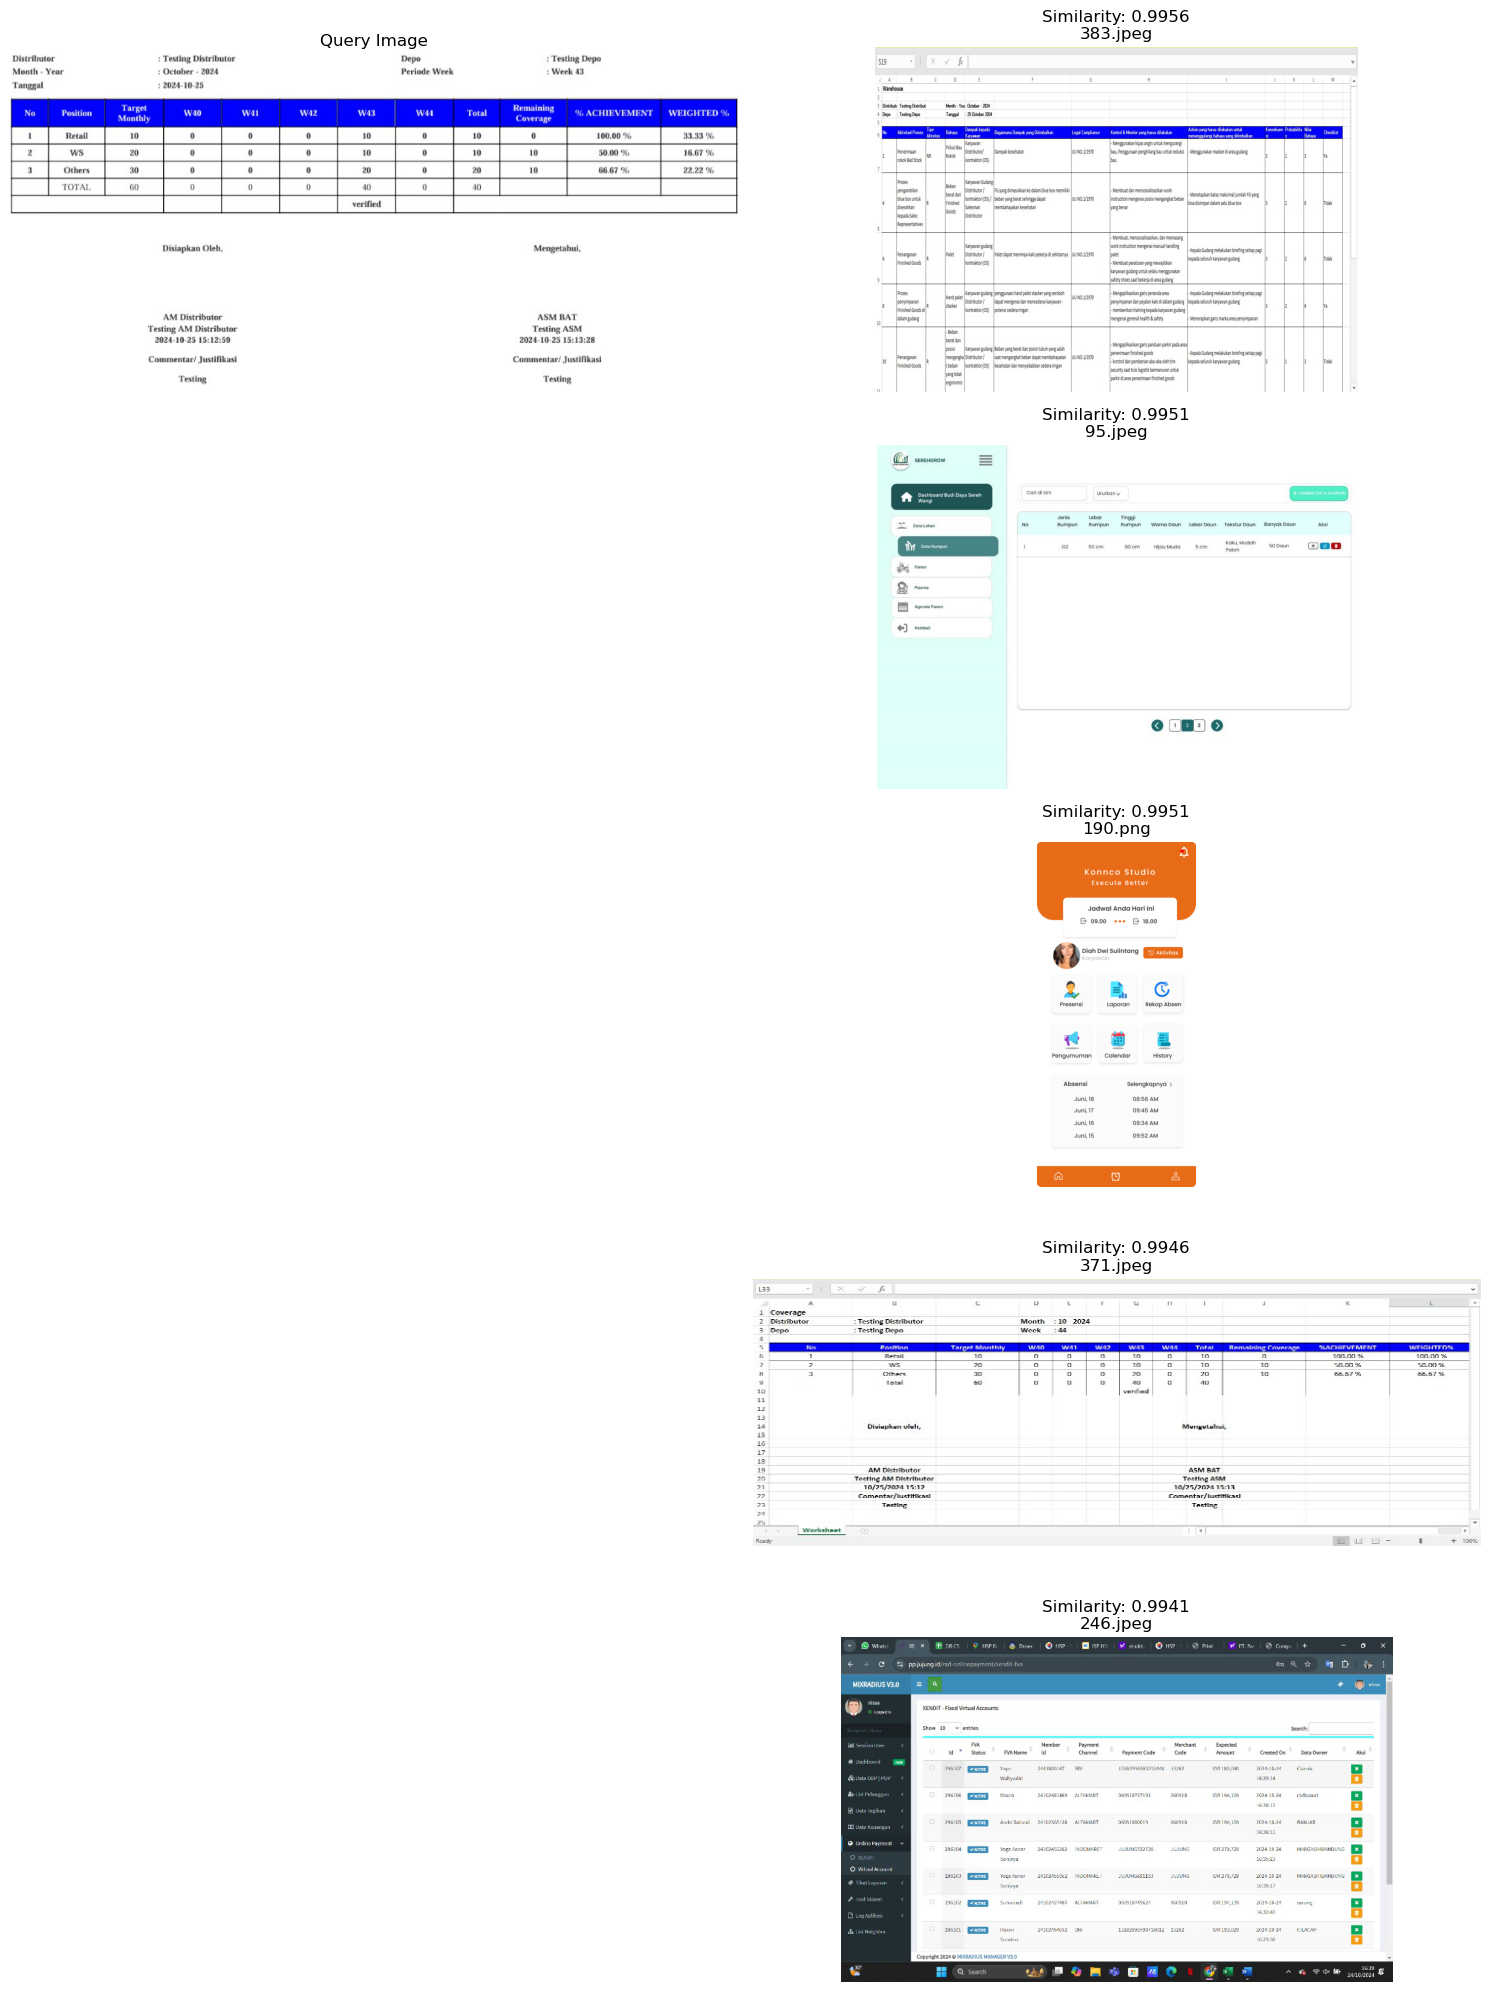

Ditemukan 490 gambar dengan similarity >= 0.95
Range similarity: 0.9502 - 0.9956

Deteksi plagiarisme untuk: 16.jpeg

Threshold: 0.95


Mendeteksi plagiarisme: 100%|██████████| 517/517 [00:50<00:00, 10.30it/s]


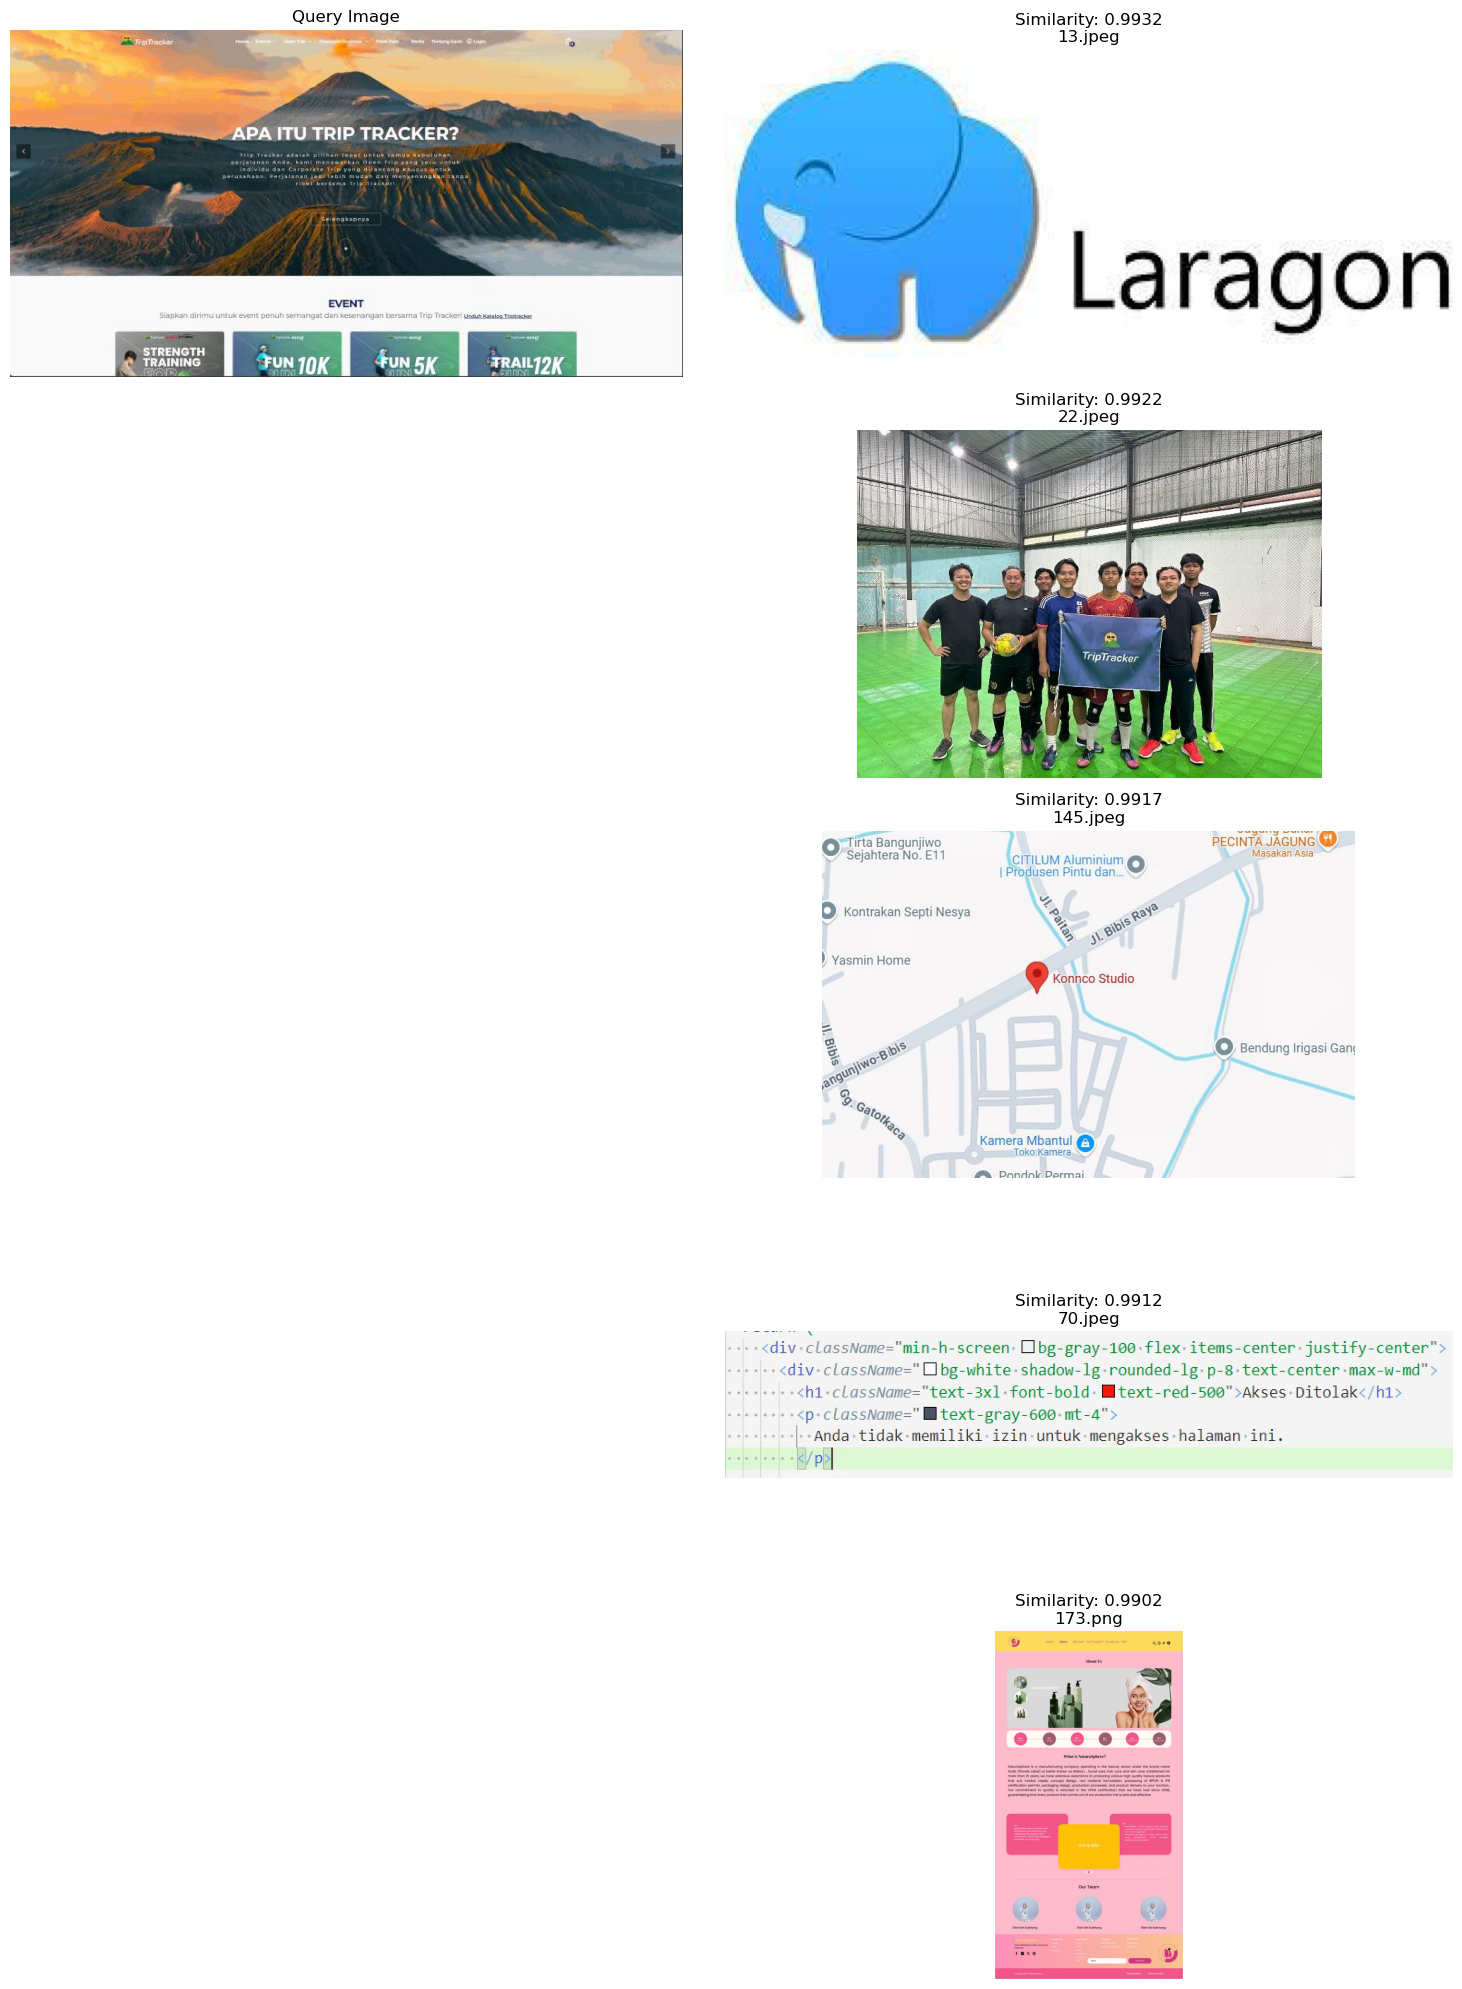

Ditemukan 512 gambar dengan similarity >= 0.95
Range similarity: 0.9512 - 0.9932

Deteksi plagiarisme untuk: 177.png

Threshold: 0.95


Mendeteksi plagiarisme: 100%|██████████| 517/517 [00:50<00:00, 10.34it/s]


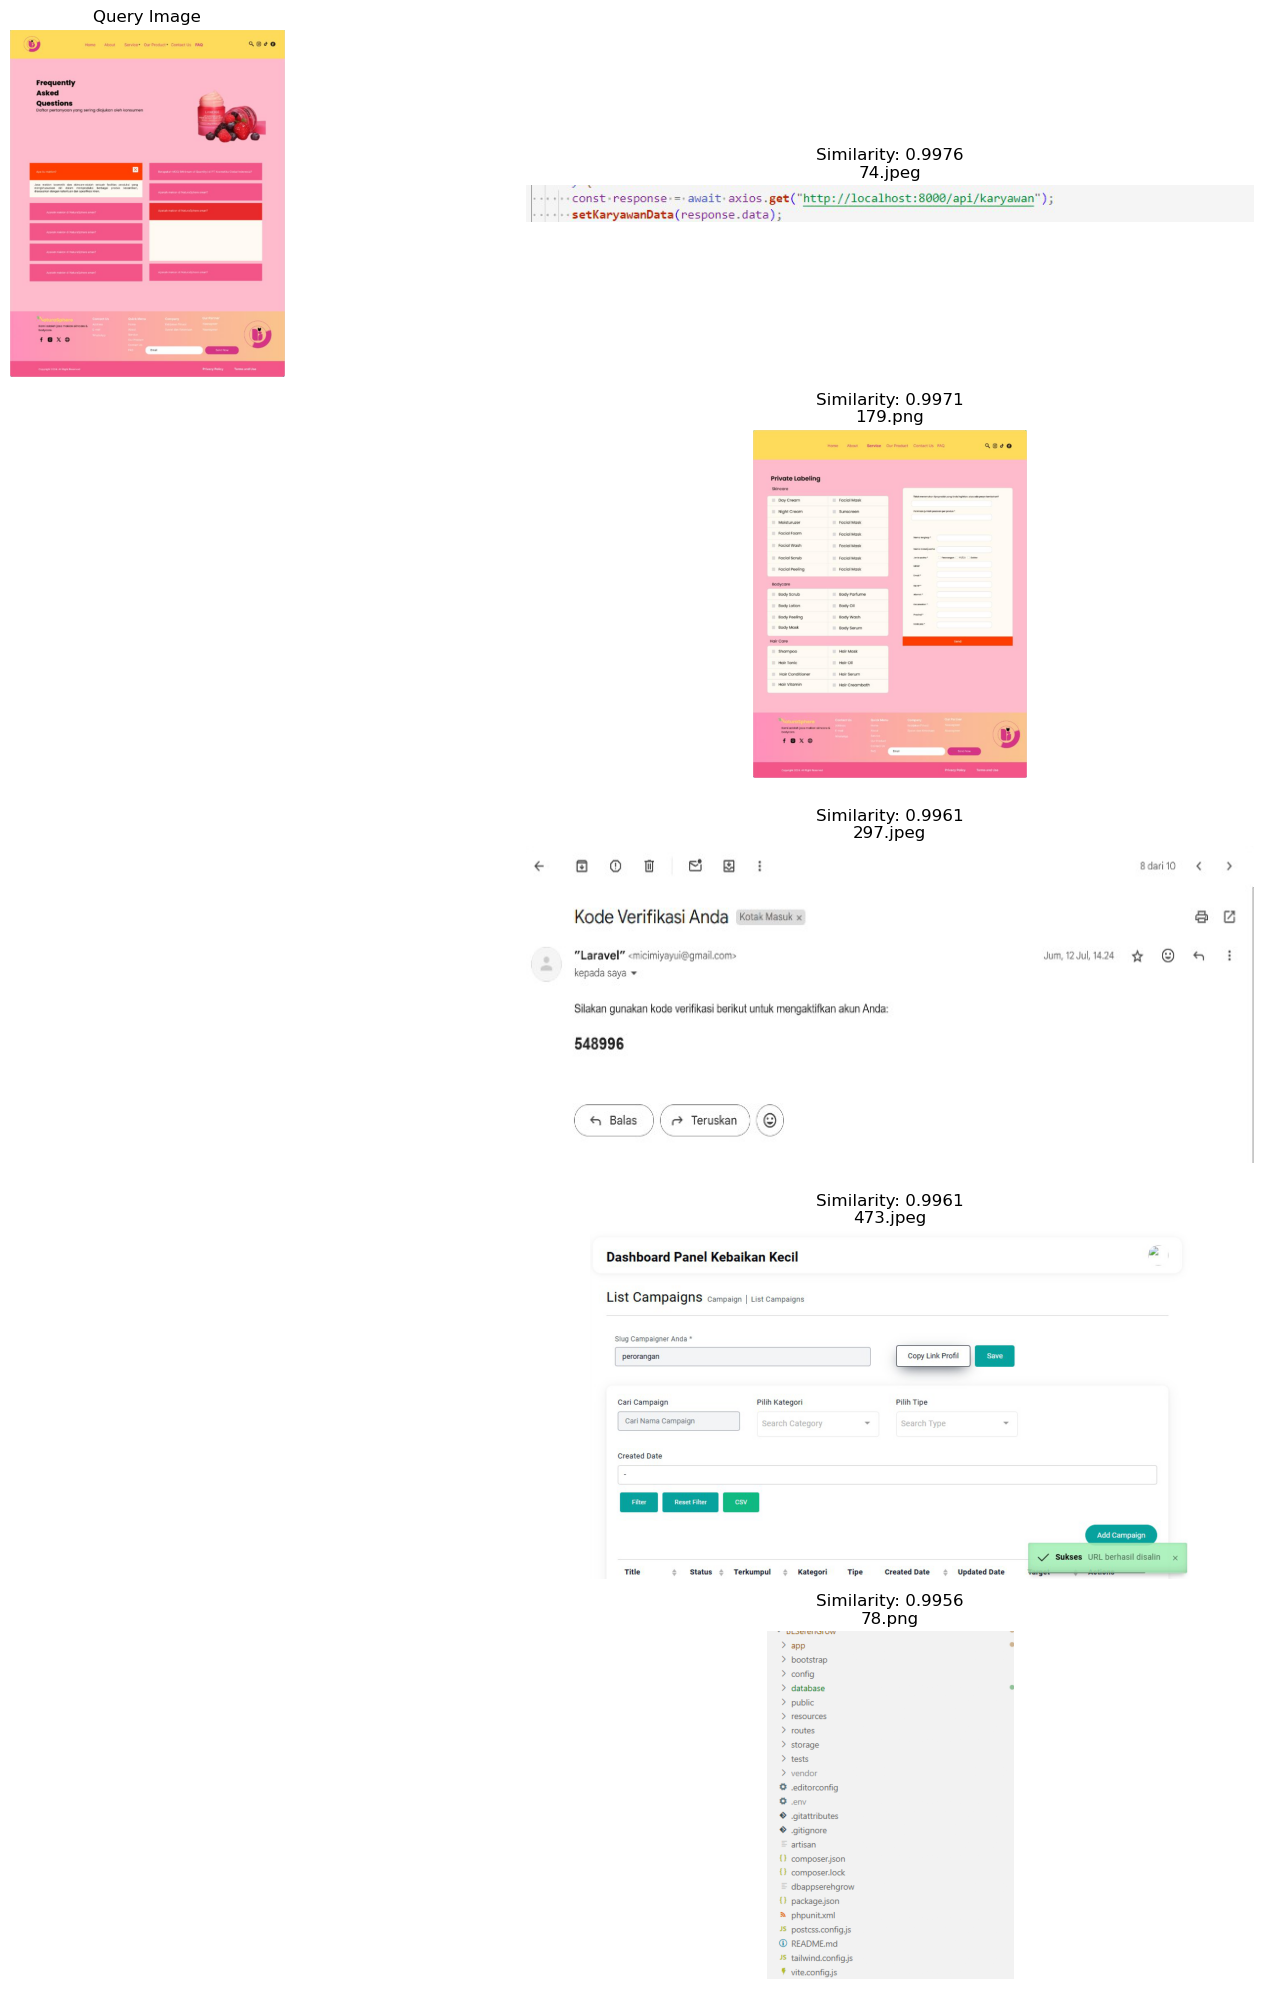

Ditemukan 508 gambar dengan similarity >= 0.95
Range similarity: 0.9517 - 0.9976


Evaluasi model dengan threshold 0.95:


Evaluasi model: 100%|██████████| 100/100 [1:20:12<00:00, 48.13s/it]

Evaluasi pada 100 gambar testing:
Average Precision: 1.0000
Average Recall: 0.9541
Average F1: 0.9710


NameError: name 'visualize_embeddings' is not defined

In [29]:
# cell [22]

# Jalankan testing
# 1. Uji dengan beberapa gambar
test_samples = random.sample(test_images, 3)
thresholds = [0.95]

for query_image in test_samples:
    print(f"\nDeteksi plagiarisme untuk: {os.path.basename(query_image)}")
    for threshold in thresholds:
        print(f"\nThreshold: {threshold}")
        results = detect_plagiarism(query_image, test_folder, embedding, threshold=threshold)
        visualize_plagiarism_results(query_image, results)

# 2. Evaluasi model untuk setiap threshold
for threshold in thresholds:
    print(f"\n\nEvaluasi model dengan threshold {threshold}:")
    metrics = evaluate_model_on_test_set(test_images, test_folder, embedding, threshold=threshold)

# 3. Visualisasi embedding
visualize_embeddings(test_images, embedding, n_samples=200)